In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(df.columns)

Index(['Project', 'Bug ID', 'Severity Label', 'Resolution Status',
       'Short Description', 'Category', 'Label'],
      dtype='object')


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/drive/My Drive/bug/eclipse_realtime.csv")

# Load a specific column (e.g., 'Short Description')
new_descriptions = df["Description "].tolist()

# print(new_descriptions[:5])  # Print first 5 descriptions


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/drive/My Drive/bug/DATASET.csv")


MULTILAYER PERCEPTRON

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Define the same model structure
class SiameseNetwork(nn.Module):
    def __init__(self, input_dim=384, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = torch.nn.functional.normalize(x, p=2, dim=1)  # L2 normalization
        return x  # Embedding output

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/content/drive/MyDrive/bug/siamese_model2.pth"  # Adjust if needed
siamese_model = SiameseNetwork().to(device)
siamese_model.load_state_dict(torch.load(model_path, map_location=device))
siamese_model.eval()  # Set model to evaluation mode
print("✅ Siamese Model Loaded Successfully!")


✅ Siamese Model Loaded Successfully!


In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Category"].astype("category").cat.categories))

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/mlp_3.pkl")

# Step 1: Convert New Data to Embeddings
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training'''

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)

predictions = np.argmax(predictions, axis=1)  # Convert to class indices
predicted_categories = [label_to_category[label] for label in predictions]




2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [ ]:
import pandas as pd

# Create a DataFrame with the descriptions and predicted categories
output_df = pd.DataFrame({"Short Description": new_descriptions, "Predicted Category": predicted_categories})

# Save to CSV
output_df.to_csv("predicted_bug_categories.csv", index=False)

print("✅ Predictions saved successfully to 'predicted_bug_categories.csv'")


✅ Predictions saved successfully to 'predicted_bug_categories.csv'


In [ ]:
!ls

drive  predicted_bug_categories.csv  sample_data


In [ ]:
import shutil
shutil.move("predicted_bug_categories.csv","/content/drive/MyDrive/bug/predicted_bug_categories.csv")

'/content/drive/MyDrive/bug/predicted_bug_categories.csv'

<ipython-input-25-3d1da9f4a190>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


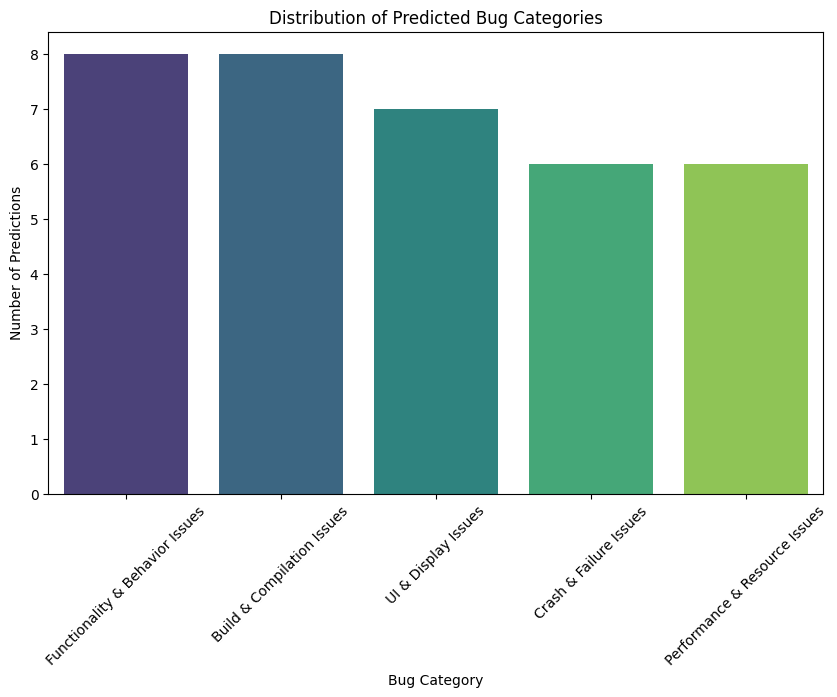

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predictions to a DataFrame
df_predictions = pd.DataFrame({'Predicted Category': predicted_categories})

# Count occurrences of each category
category_counts = df_predictions['Predicted Category'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xlabel("Bug Category")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Predicted Bug Categories")
plt.xticks(rotation=45)  # Rotate labels for better visibility
plt.show()


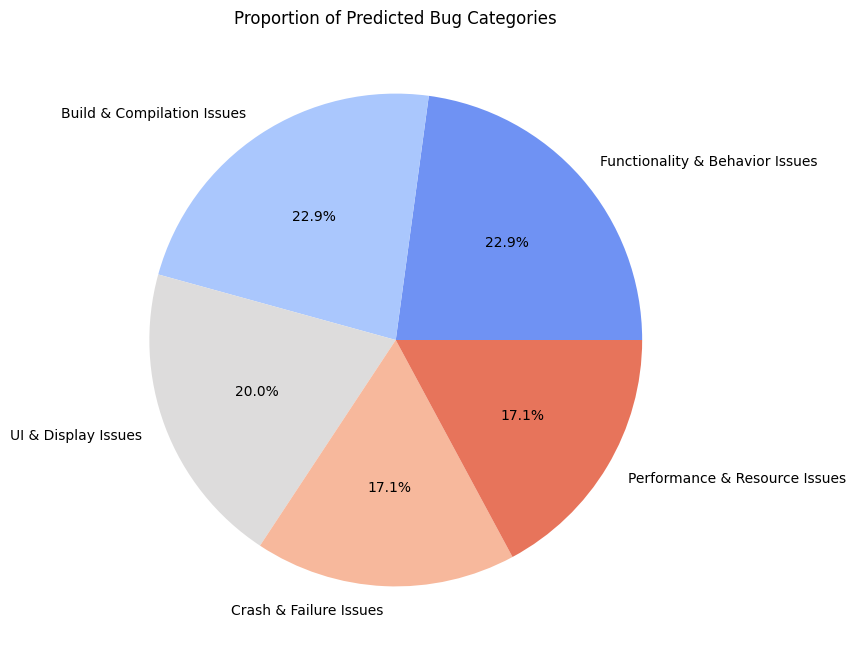

In [ ]:
# Get value counts for each category
category_counts = df_predictions["Predicted Category"].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", colors=sns.color_palette("coolwarm", len(category_counts)))
plt.title("Proportion of Predicted Bug Categories")
plt.show()


RANDOM FOREST

In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Category"].astype("category").cat.categories))

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/rf_classifier.pkl")

# Step 1: Convert New Data to Embeddings
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training'''

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)

predictions = np.argmax(predictions, axis=1)  # Convert to class indices
predicted_categories = [label_to_category[label] for label in predictions]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


In [ ]:
import pandas as pd

# Create a DataFrame with the descriptions and predicted categories
output_df = pd.DataFrame({"Short Description": new_descriptions, "Predicted Category": predicted_categories})

# Save to CSV
output_df.to_csv("predicted_bug_categories_rf.csv", index=False)

print("✅ Predictions saved successfully to 'predicted_bug_categories_rf.csv'")


✅ Predictions saved successfully to 'predicted_bug_categories_rf.csv'


In [ ]:
import shutil
shutil.move("predicted_bug_categories_rf.csv","/content/drive/MyDrive/bug/predicted_bug_categories_rf.csv")

'/content/drive/MyDrive/bug/predicted_bug_categories_rf.csv'

<ipython-input-60-3d1da9f4a190>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


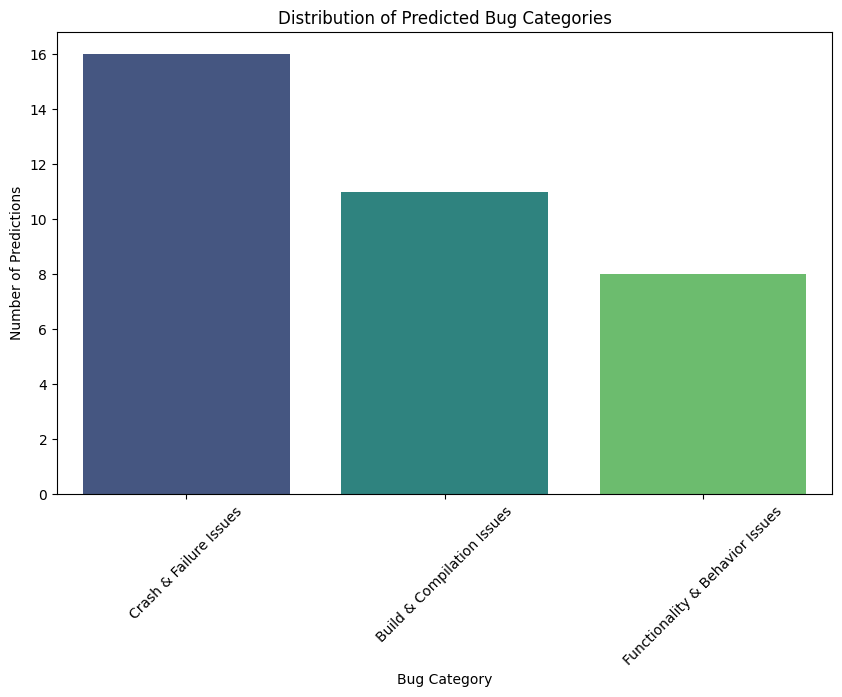

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predictions to a DataFrame
df_predictions = pd.DataFrame({'Predicted Category': predicted_categories})

# Count occurrences of each category
category_counts = df_predictions['Predicted Category'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xlabel("Bug Category")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Predicted Bug Categories")
plt.xticks(rotation=45)  # Rotate labels for better visibility
plt.show()


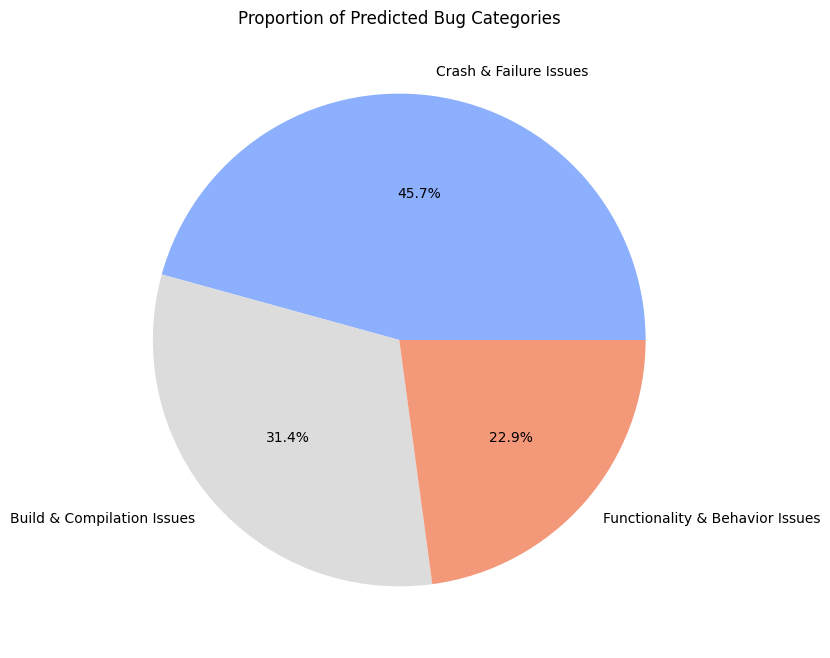

In [ ]:
# Get value counts for each category
category_counts = df_predictions["Predicted Category"].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", colors=sns.color_palette("coolwarm", len(category_counts)))
plt.title("Proportion of Predicted Bug Categories")
plt.show()


In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Category"].astype("category").cat.categories))

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/xgb_classifier.pkl")

# Step 1: Convert New Data to Embeddings
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training'''

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)

predictions = np.argmax(predictions, axis=1)  # Convert to class indices
predicted_categories = [label_to_category[label] for label in predictions]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


In [ ]:
import pandas as pd

# Create a DataFrame with the descriptions and predicted categories
output_df = pd.DataFrame({"Short Description": new_descriptions, "Predicted Category": predicted_categories})

# Save to CSV
output_df.to_csv("predicted_bug_categories_xgb.csv", index=False)

print("✅ Predictions saved successfully to 'predicted_bug_categories_xgb.csv'")


✅ Predictions saved successfully to 'predicted_bug_categories_xgb.csv'


In [ ]:
import shutil
shutil.move("predicted_bug_categories_xgb.csv","/content/drive/MyDrive/bug/predicted_bug_categories_xgb.csv")

'/content/drive/MyDrive/bug/predicted_bug_categories_xgb.csv'

<ipython-input-48-3d1da9f4a190>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


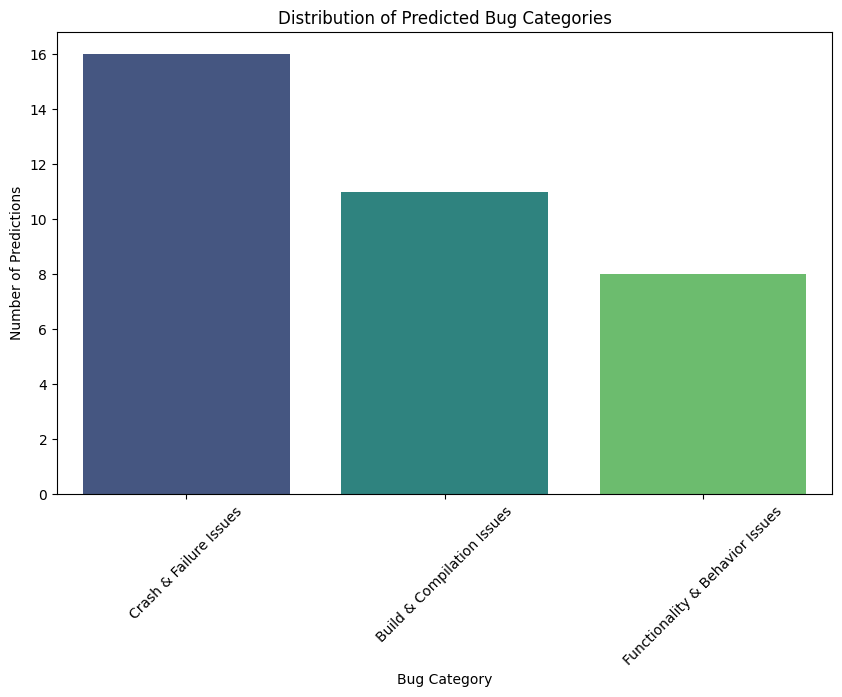

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predictions to a DataFrame
df_predictions = pd.DataFrame({'Predicted Category': predicted_categories})

# Count occurrences of each category
category_counts = df_predictions['Predicted Category'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xlabel("Bug Category")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Predicted Bug Categories")
plt.xticks(rotation=45)  # Rotate labels for better visibility
plt.show()


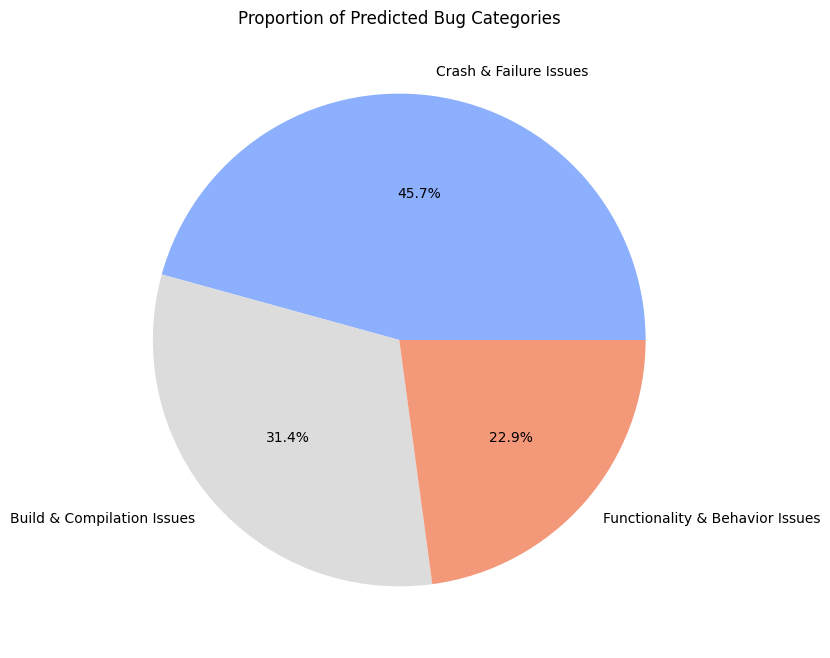

In [ ]:
# Get value counts for each category
category_counts = df_predictions["Predicted Category"].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", colors=sns.color_palette("coolwarm", len(category_counts)))
plt.title("Proportion of Predicted Bug Categories")
plt.show()


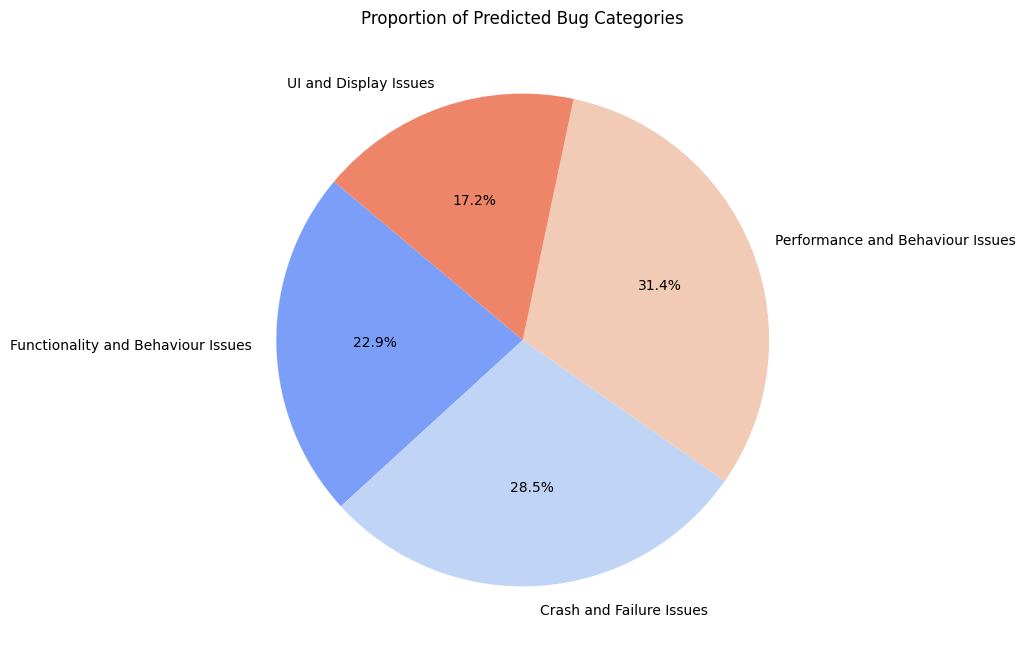

In [ ]:
import matplotlib.pyplot as plt

# Data
models = ["Functionality and Behaviour Issues", "Crash and Failure Issues", "Performance and Behaviour Issues", "UI and Display Issues"]
accuracy = [22.9, 28.5, 31.4, 17.2]  # Accuracy values in percentage

# Create Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(accuracy, labels=models, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("coolwarm", 4))

# Title
plt.title("Proportion of Predicted Bug Categories")

# Show Chart
plt.show()